In [ ]:
#Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_In = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

In [4]:
df_DA_In = df_DA_In.dropna(subset=['salary_year_avg'])
df_DA_In_explode = df_DA_In.explode('job_skills')
df_DA_In_explode[['salary_year_avg','job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [6]:
df_DA_skills =df_DA_In_explode.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})
DA_job_count = len(df_DA_In)
df_DA_skills['skill_percent'] = df_DA_skills['skill_count']/DA_job_count * 100
skill_percent = 5
df_DA_skills_High_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]
df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,46,96050.0,48.936170
excel,39,98500.0,41.489362
python,36,96050.0,38.297872
tableau,20,108087.5,21.276596
r,18,79200.0,19.148936
...,...,...,...
unify,1,79200.0,1.063830
unreal,1,105650.0,1.063830
visio,1,119250.0,1.063830


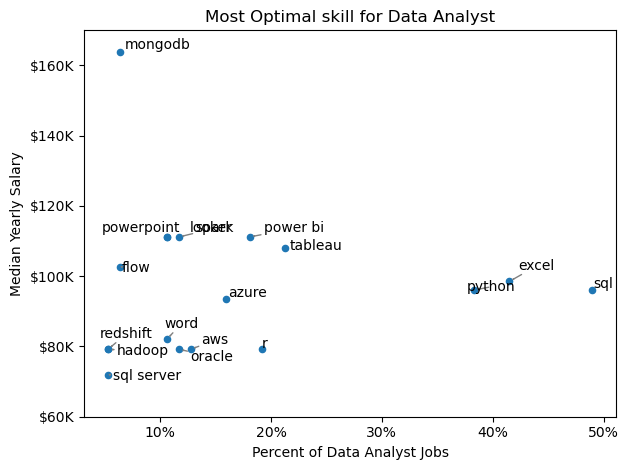

In [36]:
from adjustText import adjust_text
df_DA_skills_High_demand.plot(kind='scatter', x='skill_percent', y='median_salary')

# Prepare Text for AdjustText
texts = []
for i, txt in enumerate(df_DA_skills_High_demand.index):
    texts.append(plt.text(df_DA_skills_High_demand['skill_percent'].iloc[i], df_DA_skills_High_demand['median_salary'].iloc[i],txt))

# Adjust text to overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->',color='gray'))

# Set axis labels, title and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal skill for Data Analyst')
plt.ylim(60000, 170000)

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()

